# Task 1 & 2 — Brent Oil Price EDA

Loads the raw Brent daily price series, checks trend / stationarity / volatility
properties, and prepares log returns ahead of the Bayesian change point model in
`2.0-bayesian-change-point.ipynb`.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

from src.data_loader import add_log_returns, load_events, load_prices

plt.rcParams["figure.figsize"] = (12, 5)


## 1. Load and clean data

In [2]:
prices = load_prices()
prices = add_log_returns(prices)
events = load_events()

print(prices.shape)
print(prices["Date"].min(), "to", prices["Date"].max())
prices.head()


(9011, 4)
1987-05-20 00:00:00 to 2022-11-14 00:00:00


,Date,Price,log_price,log_return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


In [3]:
# Sanity checks: no duplicate dates, no missing prices
assert prices["Date"].is_unique, "duplicate dates found"
assert prices["Price"].isna().sum() == 0, "missing prices found"
prices["Price"].describe()


count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64

## 2. Raw price series

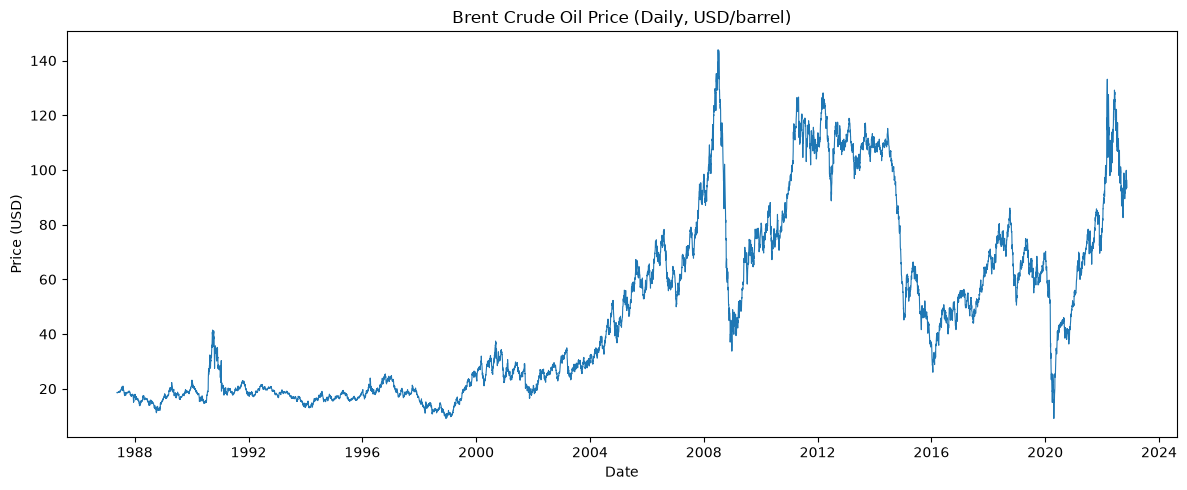

In [4]:
fig, ax = plt.subplots()
ax.plot(prices["Date"], prices["Price"], linewidth=0.8)
ax.set_title("Brent Crude Oil Price (Daily, USD/barrel)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("../reports/figures/01_raw_price_series.png", dpi=150)
plt.show()


## 3. Log returns

Log returns `r_t = log(P_t) - log(P_{t-1})` are used as a (closer to) stationary
target for the change point model, and to visualize volatility clustering.


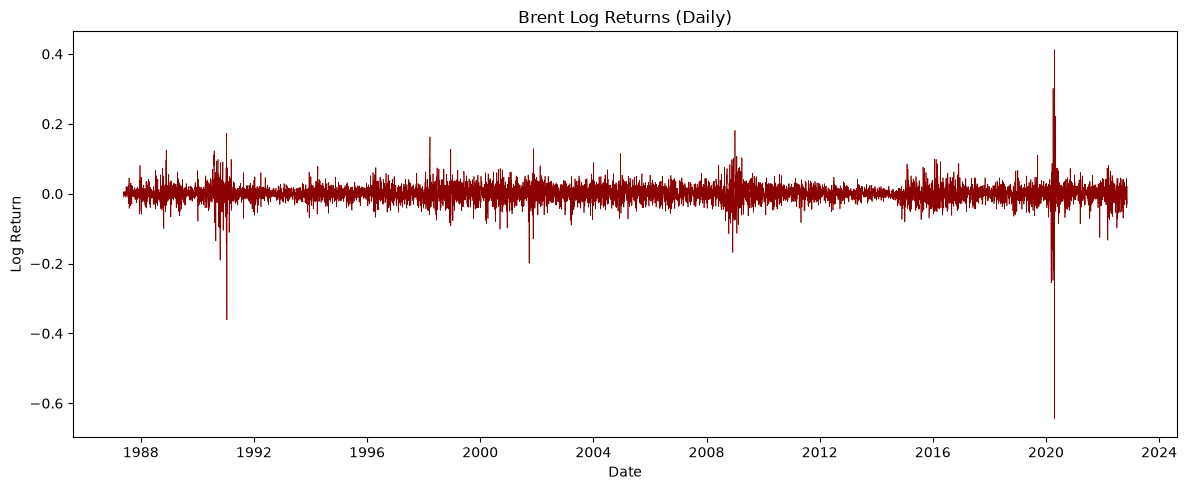

In [5]:
fig, ax = plt.subplots()
ax.plot(prices["Date"], prices["log_return"], linewidth=0.5, color="darkred")
ax.set_title("Brent Log Returns (Daily)")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.tight_layout()
plt.savefig("../reports/figures/02_log_returns.png", dpi=150)
plt.show()


## 4. Stationarity testing (Augmented Dickey-Fuller)

In [6]:
def adf_report(series: pd.Series, label: str) -> dict:
    series = series.dropna()
    stat, pvalue, *_ = adfuller(series)
    stationary = pvalue < 0.05
    print(f"{label}: ADF stat={stat:.3f}, p-value={pvalue:.4f}, stationary={stationary}")
    return {"series": label, "adf_stat": stat, "p_value": pvalue, "stationary": stationary}


results = [
    adf_report(prices["Price"], "Price (level)"),
    adf_report(prices["log_return"], "Log Return"),
]
pd.DataFrame(results)


Price (level): ADF stat=-1.994, p-value=0.2893, stationary=False
Log Return: ADF stat=-16.427, p-value=0.0000, stationary=True


,series,adf_stat,p_value,stationary
0,Price (level),-1.993856,2.892735e-01,False
1,Log Return,-16.427113,2.498580e-29,True


**Expected interpretation:** the price level is expected to fail to reject the unit-root
null (non-stationary), while log returns are expected to strongly reject it (stationary) —
consistent with standard behavior of financial price series vs. returns.


## 5. Volatility clustering (rolling std of log returns)

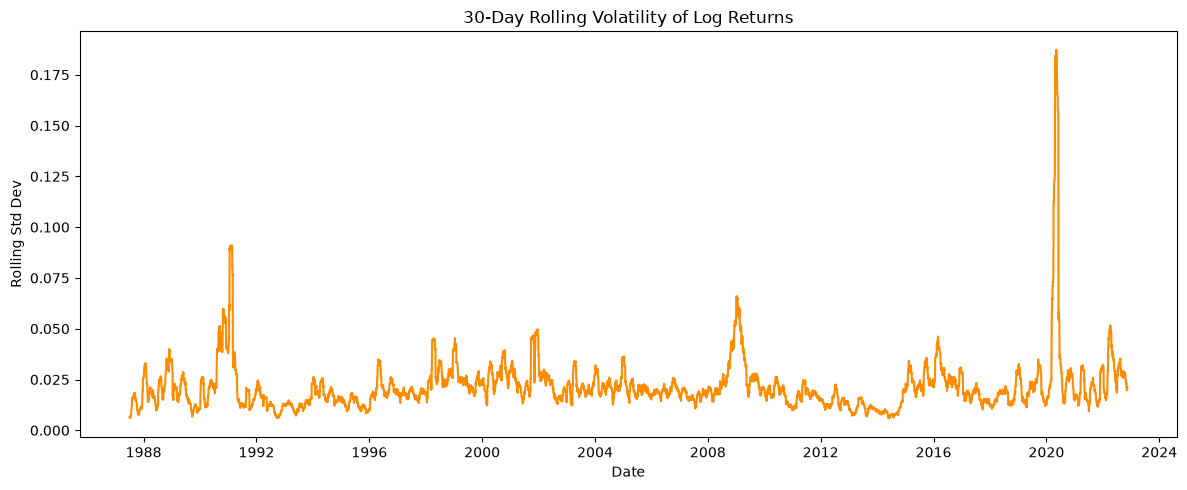

In [7]:
prices["rolling_volatility_30d"] = prices["log_return"].rolling(30).std()

fig, ax = plt.subplots()
ax.plot(prices["Date"], prices["rolling_volatility_30d"], color="darkorange")
ax.set_title("30-Day Rolling Volatility of Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std Dev")
plt.tight_layout()
plt.savefig("../reports/figures/03_rolling_volatility.png", dpi=150)
plt.show()


## 6. Key events overlay

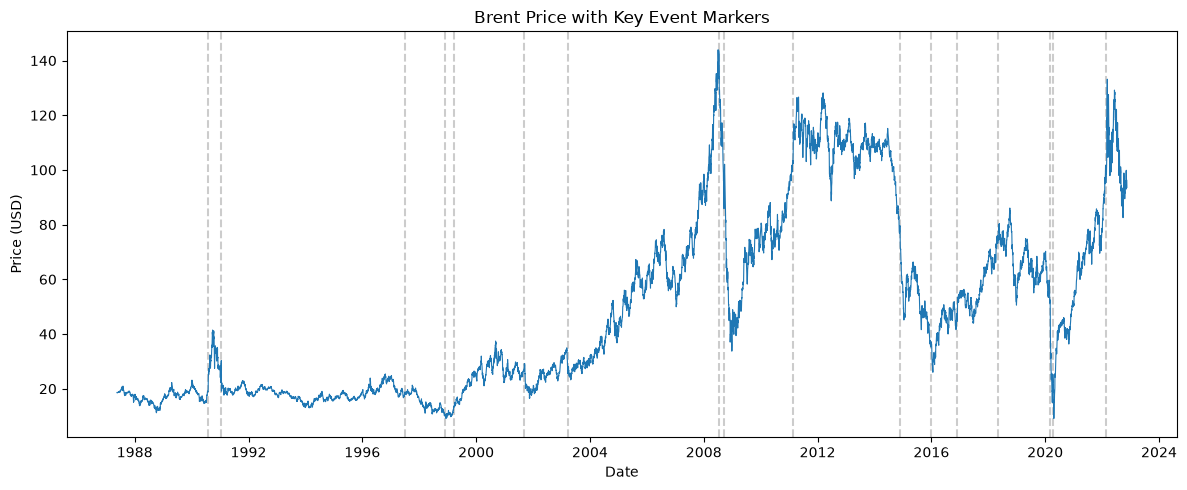

In [8]:
fig, ax = plt.subplots()
ax.plot(prices["Date"], prices["Price"], linewidth=0.8, zorder=1)
for _, row in events.iterrows():
    ax.axvline(row["date"], color="grey", linestyle="--", alpha=0.4, zorder=0)
ax.set_title("Brent Price with Key Event Markers")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("../reports/figures/04_price_with_events.png", dpi=150)
plt.show()


In [9]:
prices.to_csv("../data/processed/brent_prices_clean.csv", index=False)
